# Error Analysis: Identify characteristics of misclassified sentences

- For the sentences that were incorrectly classified, what are the characteristics in them?
- For the ones that are classified as a prediction, do our prediction properties exist?

---

## TODOs

1. Majority Vote (mv): to get the ultimate $ y_{hat} $ label
    1. Do models (mv) tend to be correct or incorrect?
2. Fliess Kappa: to measure agreement
    1. Do models tend to agree and be correct or incorrect?
3. K-Means: plotting where

In [1]:
import os
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
# combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/combined_generated_fin_phrase_bank')
train_data = os.path.join(base_data_path, 'classification_results/train_synthetic-v1_2026-03-23/seed3')

In [4]:
# model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
test_data = os.path.join(train_data, 'external_fpb-maya-binary-imbalanced-96d-v1/', 'ml_classifiers_fpb-maya-binary-imbalanced-96d-v1.csv')

model_results_df = DataProcessing.load_from_file(test_data, 'csv', sep=',')
cols_to_drop = ["Dataset Name", "Author Type", "maya_label"]
compare_y_vs_yhats_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)
compare_y_vs_yhats_df

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.94305294e-03 1.57299116e-01 -1.01663664e-01 -4.74716797e-02\n 1.79840446e-01 2.63532978e-02 4.07044962e-02 -3.17418873e-02\n -1.32127828e-03 1.28309309e+00 -3.01563025e-01 4.19499092e-02\n 4.76229452e-02 -1.16947450e-01 -1.42535036e-02 2.37643998e-02\n -3.57760116e-02 8.38545859e-01 -5.43218441e-02 2.42432952e-03\n 7.67285563e-03 4.88467440e-02 4.74129207e-02 -2.67546187e-04\n 6.47759363e-02 7.66171236e-03 -7.71588413e-03 6.14660196e-02\n 9.25298501e-03 1.29891783e-01 6.76145032e-02 -7.35822739e-03\n 3.22291143e-02 1.50113806e-01 1.32441163e-01 -9.81159508e-03\n -1.3941115

In [5]:
model_col_names = compare_y_vs_yhats_df.columns.to_list()[3:]
model_col_names, len(model_col_names)

(['perceptron',
  'sgd_classifier',
  'logistic_regression',
  'ridge_classifier',
  'decision_tree_classifier',
  'random_forest_classifier',
  'gradient_boosting_classifier',
  'support_vector_machine_classifier',
  'x_gradient_boosting_classifier'],
 9)

In [6]:
compare_y_vs_mv_df = compare_y_vs_yhats_df[model_col_names].mode(axis=1)
compare_y_vs_yhats_df['Majority Vote'] = compare_y_vs_mv_df
model_col_names.append('Majority Vote')
compare_y_vs_yhats_df

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.94305294e-03 1.57299116e-01 -1.01663664e-01 -4.74716797e-02\n 1.79840446e-01 2.63532978e-02 4.07044962e-02 -3.17418873e-02\n -1.32127828e-03 1.28309309e+00 -3.01563025e-01 4.19499092e-02\n 4.76229452e-02 -1.16947450e-01 -1.42535036e-02 2.37643998e-02\n -3.57760116e-02 8.38545859e-01 -5.43218441e-02 2.42432952e-03\n 7.67285563e-03 4.88467440e-02 4.74129207e-02 -2.67546187e-04\n 6.47759363e-02 7.66171236e-03 -7.71588413e-03 6.14660196e-02\n 9.25298501e-03 1.29891783e-01 6.76145032e-02 -7.35822739e-03\n 3.22291143e-02 1.50113806e-01 1.32441163e-01 -9.81159

In [7]:
model_col_names

['perceptron',
 'sgd_classifier',
 'logistic_regression',
 'ridge_classifier',
 'decision_tree_classifier',
 'random_forest_classifier',
 'gradient_boosting_classifier',
 'support_vector_machine_classifier',
 'x_gradient_boosting_classifier',
 'Majority Vote']

## Get misalignment 

- Per y and $y_{hat}$
- Per model
- Possibly realign where all models disagree on misalignment. Or, maybe not as worse case could be they misalign?

In [8]:
def get_misclassified_sentences(df, model_col_names):
    classification_dfs = []
    tps, fns, tns, fps = [], [], [], []

    for idx, row in df.iterrows():
        sentence = row['Base Sentence']
        y = row['Sentence Label']
        embedding = row["Base Sentence Embedding"]

        for model_col_name in model_col_names:
            y_hat = row[model_col_name]

            # y = 1 (positive class)
            if y == 1:
                if y_hat == 1:  # TP
                    tps.append((idx, sentence, y, y_hat, model_col_name, embedding))
                else:  # FN
                    fn = (idx, sentence, y, y_hat, model_col_name, embedding)
                    fns.append(fn)
                    if idx < 3:
                        print(f"{idx}-{sentence}")
                        print(f"\tMismatch: {fn}")

            # y = 0 (negative class)
            elif y == 0:
                if y_hat == 0:  # TN
                    tns.append((idx, sentence, y, y_hat, model_col_name, embedding))
                else:  # FP
                    fp = (idx, sentence, y, y_hat, model_col_name, embedding)
                    fps.append(fp)
                    if idx < 3:
                        print(f"{idx}-{sentence}")
                        print(f"\tMismatch: {fp}")

    # Build outputs
    col_names = ["Row", "Sentence", "True Label", "Model Label", "Model Name", "Embedding"]
    tps_df = pd.DataFrame(tps, columns=col_names)
    classification_dfs.append(tps_df)

    tns_df = pd.DataFrame(tns, columns=col_names)
    classification_dfs.append(tns_df)

    fns_df = pd.DataFrame(fns, columns=col_names)
    classification_dfs.append(fns_df)

    fps_df = pd.DataFrame(fps, columns=col_names)
    classification_dfs.append(fps_df)


    return classification_dfs

In [9]:
classification_dfs = get_misclassified_sentences(compare_y_vs_yhats_df, model_col_names)

0-With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .
	Mismatch: (0, 'With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .', 1, 0, 'decision_tree_classifier', '[-1.22568220e-01  2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02  3.63291465e-02 -1.27964811e-02  7.17335939e-02\n -1.18364163e-01  2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n  1.25499114e-01  7.25146085e-02  6.57393187e-02 -5.76901138e-02\n -2.05907249e-03  1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n  2.22120117e-02  1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03  6.18153140e-02 -5.48806489e-02  2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02  3.87728140e-02\n -5

| $ y $ | $ y_{hat} $ | Outcome |
|----------------|----------------|----------|
| 1              | 1              | **TP**   |
| 1              | 0              | **FN**  (miss out) |
| 0              | 0              | **TN**   |
| 0              | 1              | **FP**  (inflate) |

**Confusion Matrix (sklearn-style layout)**

| y \ y_hat |   0   |   1   |
|-----------|-------|-------|
| **0**     |  TN   |  FP  (inflate) |
| **1**     |  FN  (miss out) |  TP   |

In [10]:
tps_df, tns_df, fns_df, fps_df = classification_dfs[0], classification_dfs[1], classification_dfs[2], classification_dfs[3]
len(tps_df), len(tns_df), len(fns_df), len(fps_df)

(3667, 25248, 913, 18632)

In [11]:
tps_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,perceptron,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
1,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,sgd_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
2,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,logistic_regression,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
3,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,ridge_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-

In [12]:
tns_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,459,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",0,0,random_forest_classifier,[ 2.36152317e-02 1.75637215e-01 -4.75921258e-02 -1.00200571e-01\n 8.89781415e-02 -6.43718988e-02 -2.69504562e-02 -4.83372882e-02\n 8.36279336e-03 2.23455858e+00 -2.08360046e-01 -7.23112794e-03\n 8.49666148e-02 1.64331440e-02 -6.58765361e-02 -4.59754653e-03\n 4.57342863e-02 1.37366998e+00 -2.09634945e-01 -1.05597727e-01\n 5.03051467e-03 6.17915466e-02 -7.04549477e-02 -7.91235566e-02\n 3.26408111e-02 -1.15197964e-01 -5.03080897e-02 5.12997098e-02\n 2.39542034e-02 -1.31541165e-02 5.15889144e-03 -1.93684064e-02\n 2.15651724e-03 3.74105498e-02 1.53509766e-01 -1.50099948e-01\n -2.85472199e-02 7.28019401e-02 1.21796988e-02 -5.34533598e-02\n 3.01733967e-02 1.60360977e-01 9.51667279e-02 -1.36446133e-01\n -4.18400392e-02 -9.26042721e-03 -9.38620940e-02 -4.67620976e-02\n 6....
1,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,perceptron,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 2.39139330e-02 9.83950123e-03\n 2.01519504e-02 6.74011931e-02 8.08727369e-02 -7.34586567e-02\n 2.04947442e-02 -5.54246791e-02 -7.21987188e-02 -1.01516275e-02\n 1....
2,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,sgd_classifier,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 2.39139330e-02 9.83950123e-03\n 2.01519504e-02 6.74011931e-02 8.08727369e-02 -7.34586567e-02\n 2.04947442e-02 -5.54246791e-02 -7.21987188e-02 -1.01516275e-02\n 1....
3,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,logistic_regression,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 

In [13]:
fns_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,0,decision_tree_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
1,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,logistic_regression,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....
2,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,ridge_classifier,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....
3,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,support_vector_machine_classifier,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644

In [14]:
fps_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,perceptron,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
1,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,sgd_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
2,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,logistic_regression,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
3,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,ridge_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
4,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,decision_tree_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.750

In [15]:
def get_mv_df(df):
    filt_mv = (df['Model Name'] == "Majority Vote")
    return df[filt_mv]

In [16]:
mv_dfs = []
for classification_df in classification_dfs:
    mv_df = get_mv_df(classification_df)
    mv_dfs.append(mv_df)

In [17]:
tps_mv_df, tns_mv_df, fns_mv_df, fps_mv_df = mv_dfs[0], mv_dfs[1], mv_dfs[2], mv_dfs[3]
len(tps_mv_df), len(tns_mv_df), len(fns_mv_df), len(fps_mv_df)

(388, 2536, 70, 1852)

In [19]:
fps_mv_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
9,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,Majority Vote,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
18,459,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",0,1,Majority Vote,[ 2.36152317e-02 1.75637215e-01 -4.75921258e-02 -1.00200571e-01\n 8.89781415e-02 -6.43718988e-02 -2.69504562e-02 -4.83372882e-02\n 8.36279336e-03 2.23455858e+00 -2.08360046e-01 -7.23112794e-03\n 8.49666148e-02 1.64331440e-02 -6.58765361e-02 -4.59754653e-03\n 4.57342863e-02 1.37366998e+00 -2.09634945e-01 -1.05597727e-01\n 5.03051467e-03 6.17915466e-02 -7.04549477e-02 -7.91235566e-02\n 3.26408111e-02 -1.15197964e-01 -5.03080897e-02 5.12997098e-02\n 2.39542034e-02 -1.31541165e-02 5.15889144e-03 -1.93684064e-02\n 2.15651724e-03 3.74105498e-02 1.53509766e-01 -1.50099948e-01\n -2.85472199e-02 7.28019401e-02 1.21796988e-02 -5.34533598e-02\n 3.01733967e-02 1.60360977e-01 9.51667279e-02 -1.36446133e-01\n -4.18400392e-02 -9.26042721e-03 -9.38620940e-02 -4.67620976e-02\n 6....
36,473,"Its board of directors will propose a dividend of EUR0 .12 per share for 2010 , up from the EUR0 .08 per share paid in 2009 .",0,1,Majority Vote,[-1.31687850e-01 1.12504549e-01 1.16494456e-02 -2.67163999e-02\n -3.56583372e-02 -6.02459237e-02 8.92892852e-02 -1.13993369e-01\n 1.42705552e-02 1.82348073e+00 -3.89135599e-01 1.58573151e-01\n 3.60858962e-02 -9.51433368e-03 -3.51401721e-03 -1.04351744e-01\n -4.07603793e-02 1.12848067e+00 -1.53742373e-01 -3.50933545e-03\n 3.96641493e-02 6.87583676e-03 -4.38601300e-02 -1.21602066e-01\n 1.31883547e-01 1.33860916e-01 -1.14144176e-01 -3.39329406e-03\n 1.02582075e-01 1.38460755e-01 1.67863071e-02 -8.58858973e-02\n -9.02971849e-02 1.32979512e-01 -1.20643713e-02 -3.31787951e-02\n -1.21340953e-01 -6.01888038e-02 -3.43275853e-02 -3.34232636e-02\n 1.52784446e-02 1.39206484e-01 1.49177745e-01 4.48596776e-02\n 7.95120075e-02 7.31440866e-03 2.32526101e-03 1.31328702e-02\n -7....
54,496,"Nyrstar has also agreed to supply to Talvivaara up to 150,000 tonnes of sulphuric acid per annum for use in Talvivaara 's leaching process during the period of supply of the zinc in concentrate .",0,1,Majority Vote,[-4.98915724e-02 2.06232026e-01 -1.91987175e-02 1.96848959e-02\n -7.42411390e-02 -5.51822770e-04 -8.50609317e-02 1.20758070e-02\n -3.30165178e-02 1.72571981e+00 -2.73508579e-01 7.56830424e-02\n 1.30799964e-01 -6.00745017e-03 8.23372602e-02 -1.19195625e-01\n 1.32015282e-02 1.28550172e+00 -2.07840264e-01 -8.90898481e-02\n 1.32158352e-02 1.91394298e-03 -1.20019615e-01 1.53571693e-02\n 8.81308503e-03 -1.71493515e-02 -3.19660306e-02 -1.48789641e-02\n -3.02280895e-02 -5.41339815e-02 -2.37301886e-02 -6.76737949e-02\n 4.56369482e-02 6.62220567e-02 3.23317684e-02 -6.64737597e-02\n -1.97172351e-02 2.67610271e-02 1.30011693e-01 -4.60078530e-02\n 1.09202527e-02 8.04828852e-02 3.21379490e-02 -1.74226344e-01\n 1.91539489e-02 -6.45306718e-04 -4.74677421e-02 3.57626118e-02\n 1....
71,513,The company supports its global customers in developing new technologies and offers

In [26]:
# Extract the embeddings from the DataFrame
data = tps_mv_df["Embedding"].values

# Convert the string representations to numpy arrays
embeddings = [np.fromstring(emb.strip('[]'), sep=' ', dtype=np.float64) for emb in data]

# Now embeddings is a list of numpy arrays, each representing an embedding vector
print(f"Number of embeddings: {len(embeddings)}")
print(f"Shape of the first embedding: {embeddings[0].shape}")

Number of embeddings: 388
Shape of the first embedding: (300,)


## Clustering

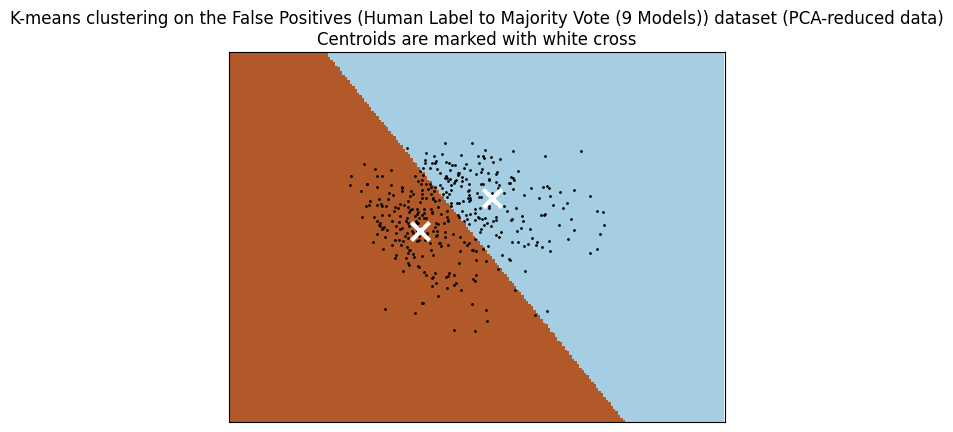

In [29]:
import matplotlib.pyplot as plt

reduced_data = PCA(n_components=2).fit_transform(embeddings)
kmeans = KMeans(init="k-means++", n_clusters=2, n_init=4)
kmeans.fit(reduced_data)

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the False Positives (Human Label to Majority Vote (9 Models)) dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()

In [ ]:
false_negative = mislabelled_pivot_table.loc[1]   # rows whose True Label == 1; given prediction, model classified as non-prediction
false_negative

In [ ]:


# 2️⃣  (Optional) reset the index if you prefer flat columns
false_positive = false_positive.reset_index()
true1_table = true1_table.reset_index()

# 3️⃣  Quick checks
print(f"Rows where True Label 0: {len(false_positive)}")
print(f"Rows where True Label 1: {len(true1_table)}")

# Now you can plot or analyse each table separately, e.g.:
#   plt.bar(true0_table['Model Name'], true0_table['Model Label'])

In [ ]:
def groupby_model_name(df, model_name):
    filt_llama = (df['Model Name'] == model_name)
    filt_df = df[filt_llama]
    return filt_df, len(filt_df)

model_dfs = []
for idx, row in misclassified_sentences_df.iterrows():
    model_name = row['Model Name']
    model_df, model_df_length = groupby_model_name(misclassified_sentences_df, model_name)
    # print(model_df)
    model_df["N Misclassified"] = model_df_length

    model_dfs.append(model_df)

In [ ]:
each_model_df = pd.concat(model_dfs)
each_model_df.head(3)

In [ ]:
len(model_results_df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1️⃣  Count the number of mismatches (i.e. rows) per model
# ------------------------------------------------------------------
miscounts = misclassified_sentences_df['Model Name'].value_counts()
misclassified_ratio = (miscounts / len(model_results_df))
properly_classified_ratio = 1 - misclassified_ratio # Should match classification
total_classified_ratio = misclassified_ratio + properly_classified_ratio
# print(f"{misclassified_ratio}, {properly_classified_ratio} = {total_classified_ratio}")
# ------------------------------------------------------------------
# 3.  Pretty‑print: one row per model, percentages to 2 decimals
# ------------------------------------------------------------------
ratios_df = pd.DataFrame({
    'Model': miscounts.index,
    'Mis‑classified': misclassified_ratio,
    'Correctly classified': properly_classified_ratio,
    'Total classified': total_classified_ratio,
    'N': len(model_results_df),
})

print(ratios_df.to_string(index=False,
                          float_format=lambda x: f'{x:.2%}'))
# ------------------------------------------------------------------
# 2️⃣  Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# bar chart: one bar per model
miscounts.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')

# aesthetics
ax.set_xlabel('Model')
ax.set_ylabel('Number of Misclassifications')
ax.set_title('Misclassifications per Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# show exact count on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1️⃣  Prepare the data ------------------------------------------------
# -------------------------------------------------------------
miscounts                = misclassified_sentences_df['Model Name'].value_counts()
misclassified_ratio      = miscounts / len(model_results_df)        # proportion that were wrong
properly_classified_ratio= 1 - misclassified_ratio                # proportion that were right
total_classified_ratio   = misclassified_ratio + properly_classified_ratio  # = 1

# DataFrame ready for printing / plotting
ratios_df = pd.DataFrame(
    {
        'Model': miscounts.index,
        'Mis‑classified': misclassified_ratio,
        'Correctly classified': properly_classified_ratio,
        'Total classified': total_classified_ratio,
        'N': len(model_results_df),
    }
)

print(ratios_df.to_string(index=False, float_format=lambda v: f'{v:.2%}'))

# -------------------------------------------------------------
# 2️⃣  Plot the stacked bar ------------------------------------
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# ── split the bars into two stacks ----------------------------
ax.bar(
    ratios_df.index,
    ratios_df['Mis‑classified'],
    width=0.8,
    color='#EB2D2D',
    label='Mis‑classified'
)

ax.bar(
    ratios_df.index,
    ratios_df['Correctly classified'],
    width=0.8,
    bottom=ratios_df['Mis‑classified'],
    color='#2EBC9B',
    label='Correctly classified'
)

# ── cosmetics --------------------------------------------------
ax.set_xlabel('Model')
ax.set_ylabel('Proportion')
ax.set_title('Mis‑classification vs Correct classification per model')
ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend()

# ── annotate bars with percentage values -----------------------
for i, (mis, cor) in enumerate(zip(ratios_df['Mis‑classified'],
                                    ratios_df['Correctly classified'])):
    ax.text(i, mis / 2, f'{mis:.1%}', ha='center', va='center', color='white', fontsize=8)
    ax.text(i, mis + cor / 2,
            f'{cor:.1%}',
            ha='center',
            va='center',
            color='white',
            fontsize=8)

plt.tight_layout()
plt.show()